# Grid-Based A* Pathfinding in Artificial Intelligence

Welcome to the hands-on computational lab for A* Search. In this notebook, the theoretical concepts of heuristic search will be transformed into an executable Python implementation.

### Learning Objectives:
1. Construct discrete graph nodes with custom priority comparison operators.
2. Implement admissible heuristics for 4-connected and 8-connected grid navigation.
3. Build the core A* graph search loop using binary min-heaps (`heapq`) and hash sets.
4. Load environment configurations (grid dimensions, obstacles, start/goal positions) from external data files (`.json`).
5. Visualize exploration frontiers and optimal path trajectories using Matplotlib.
6. Benchmark A* against Uniform Cost Search and Greedy Best-First Search.

In [ ]:
import heapq
import json
import time
from typing import List, Tuple, Dict, Set, Optional, Callable
import numpy as np
import matplotlib.pyplot as plt

# Global formatting configuration for visual consistency
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

print("Environment libraries successfully imported.")

Environment libraries successfully imported.


## Module 1: Node Representation and State Priority

Search algorithms require data structures that track spatial coordinates, path histories, and priority values.

Each state in our search space is wrapped inside a `Node` object. The node maintains references to its positional coordinates, its parent node (allowing path reconstruction once the goal is reached), and its cost attributes ($g$, $h$, and $f$).

When managing the priority queue (the Open Set), Python's binary heap (`heapq`) extracts elements based on the less-than operator (`__lt__`). Overriding this operator establishes priority ordering primarily by $f(n)$, with a secondary tie-breaker on $h(n)$. Tie-breaking on lower $h(n)$ values forces the search algorithm to favor nodes closer to the destination when total estimated costs are equal, avoiding unnecessary state expansions.

In [ ]:
class Node:
    """
    Represents a discrete state node within the A* search space.
    """
    def __init__(self, position: Tuple[int, int], parent: Optional['Node'] = None, g: float = 0.0, h: float = 0.0):
        self.position = position  # Grid coordinate tuple: (row, column)
        self.parent = parent      # Reference to predecessor Node for path backtracking
        self.g = g                # Exact cumulative path cost from start node
        self.h = h                # Estimated heuristic cost from current node to goal
        self.f = g + h            # Total evaluation function priority

    def __lt__(self, other: 'Node') -> bool:
        """
        Primary queue priority defined by lowest f-value.
        Secondary tie-breaking prioritized by lowest h-value (closer to goal).
        """
        if np.isclose(self.f, other.f):
            return self.h < other.h
        return self.f < other.f

    def __eq__(self, other: object) -> bool:
        if not isinstance(other, Node):
            return False
        return self.position == other.position

    def __hash__(self) -> int:
        return hash(self.position)

## Module 2: Spatial Distance Heuristics

The performance of A* depends on the alignment between the heuristic distance function and the allowed physical movements on the grid.

### 1. Manhattan Distance ($L_1$ Norm)
Used when movement is strictly restricted to 4 cardinal directions (Up, Down, Left, Right) with unit cost $D = 1$:

$$h(n) = \vert{}x_n - x_g\vert{} + \vert{}y_n - y_g\vert{}$$

### 2. Euclidean Distance ($L_2$ Norm)
Calculates straight-line continuous Euclidean distance. On a 4-connected discrete grid, Euclidean distance acts as an admissible under-estimator, but produces a looser lower bound than Manhattan distance, expanding a larger search frontier:

$$h(n) = \sqrt{(x_n - x_g)^2 + (y_n - y_g)^2}$$

### 3. Octile Distance ($L_\infty$ Diagonal Metric)
Designed for 8-connected grids allowing horizontal, vertical, and diagonal movements. Assuming cardinal step cost $D_1 = 1$ and diagonal step cost $D_2 = \sqrt{2}$:

$$h(n) = D_1 \cdot (\Delta x + \Delta y) + (D_2 - 2 D_1) \cdot \min(\Delta x, \Delta y)$$

In [ ]:
def manhattan_distance(p1: Tuple[int, int], p2: Tuple[int, int]) -> float:
    """Calculates Manhattan distance for 4-connected grid pathfinding."""
    return float(abs(p1[0] - p2[0]) + abs(p1[1] - p2[1]))

def euclidean_distance(p1: Tuple[int, int], p2: Tuple[int, int]) -> float:
    """Calculates Euclidean distance for continuous spatial estimation."""
    return float(np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2))

def octile_distance(p1: Tuple[int, int], p2: Tuple[int, int]) -> float:
    """Calculates Octile distance for 8-connected grid movement."""
    dx = abs(p1[0] - p2[0])
    dy = abs(p1[1] - p2[1])
    d1 = 1.0
    d2 = np.sqrt(2)
    return float(d1 * (dx + dy) + (d2 - 2 * d1) * min(dx, dy))

## Module 3: The A* Graph Search Engine

The core algorithm coordinates two primary data structures:
1. **Open Set (Priority Queue & Hash Map):** Holds discovered nodes pending evaluation, sorted by minimum $f(n)$ via a priority queue. An auxiliary dictionary maps coordinates to node instances to support $\mathcal{O}(1)$ target lookups.
2. **Closed Set (Hash Set):** Stores positions that have already been expanded, preventing re-evaluation and infinite loops in cyclic graphs.

### Algorithm Workflow:
1. Initialize the start node, compute its heuristic value, push it to the priority queue, and record it in the open map.
2. While the priority queue contains unvisited nodes, extract node $N$ with the lowest $f(N)$.
3. If $N$'s coordinate matches the target destination, backtrack through parent pointers to construct the optimal path.
4. Move $N$ to the closed set.
5. Evaluate all valid adjacent neighbors. If a neighbor is bounded, unblocked, and not closed, calculate its tentative path cost $g(N_{\text{neighbor}}) = g(N) + \text{step_cost}$.
6. If the neighbor is absent from the open map or yields a lower $g$-cost than previously recorded, update its values and insert it into the priority queue.

In [ ]:
def astar_search(
    grid: np.ndarray,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    heuristic_fn: Callable[[Tuple[int, int], Tuple[int, int]], float] = manhattan_distance,
    allow_diagonal: bool = False
) -> Tuple[Optional[List[Tuple[int, int]]], List[Tuple[int, int]], float]:
    """
    Executes graph-based A* search on a 2D grid matrix.

    Parameters:
        grid: 2D numpy array where 0 = walkable cell and 1 = impassable obstacle.
        start: Starting grid coordinate (row, col).
        goal: Target grid coordinate (row, col).
        heuristic_fn: Distance estimation function.
        allow_diagonal: If True, enables 8-directional movement; otherwise 4-directional.

    Returns:
        path: Ordered list of coordinates from start to goal (None if path unavailable).
        explored_order: Chronological sequence of expanded coordinates for visualization.
        total_cost: Cumulative path cost g(goal).
    """
    rows, cols = grid.shape
    start_node = Node(position=start, parent=None, g=0.0, h=heuristic_fn(start, goal))

    open_heap: List[Node] = []
    heapq.heappush(open_heap, start_node)

    open_dict: Dict[Tuple[int, int], Node] = {start: start_node}
    closed_set: Set[Tuple[int, int]] = set()
    explored_order: List[Tuple[int, int]] = []

    if allow_diagonal:
        directions = [
            (-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
            (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)),
            (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))
        ]
    else:
        directions = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0)]

    while open_heap:
        current_node = heapq.heappop(open_heap)
        current_pos = current_node.position

        if current_pos in closed_set:
            continue

        closed_set.add(current_pos)
        explored_order.append(current_pos)

        # Check if goal state reached
        if current_pos == goal:
            path = []
            curr: Optional[Node] = current_node
            while curr is not None:
                path.append(curr.position)
                curr = curr.parent
            return path[::-1], explored_order, current_node.g

        for dr, dc, step_cost in directions:
            neighbor_pos = (current_pos[0] + dr, current_pos[1] + dc)

            # Boundary checking
            if not (0 <= neighbor_pos[0] < rows and 0 <= neighbor_pos[1] < cols):
                continue
            # Obstacle checking
            if grid[neighbor_pos[0], neighbor_pos[1]] == 1:
                continue
            # Closed set validation
            if neighbor_pos in closed_set:
                continue

            tentative_g = current_node.g + step_cost

            # Check if neighbor in open set with better g cost
            if neighbor_pos in open_dict and tentative_g >= open_dict[neighbor_pos].g:
                continue

            neighbor_node = Node(
                position=neighbor_pos,
                parent=current_node,
                g=tentative_g,
                h=heuristic_fn(neighbor_pos, goal)
            )

            open_dict[neighbor_pos] = neighbor_node
            heapq.heappush(open_heap, neighbor_node)

    return None, explored_order, float('inf')

## Module 4: External Data Management and Data Loader Pipeline

To promote code reuse and software engineering best practices, environment data is loaded from an external structured JSON file (`input_grid.json`).

### Input File Structure Specification (`input_grid.json`):
```json
{
  "dimensions": [20, 20],
  "start": [0, 0],
  "goal": [19, 19],
  "obstacles": [
    [4, 6], [5, 6], [6, 6]
  ]
}
```

The data loader function `load_environment_from_json()` reads the specified JSON input file, initializes a 2D NumPy array matrix of size `dimensions`, marks wall obstacle coordinates as `1`, and extracts `start` and `goal` coordinates as coordinate tuples.

In [ ]:
# Create sample external input file (input_grid.json) programmatically
sample_input_data = {
    "dimensions": [20, 20],
    "start": [0, 0],
    "goal": [19, 19],
    "obstacles": (
        [[r, 6] for r in range(4, 16)] +   # Wall 1: Column 6, Rows 4-15
        [[7, r] for r in range(0, 13)] +   # Wall 2: Row 7, Columns 0-12
        [[r, 13] for r in range(2, 14)]    # Wall 3: Column 13, Rows 2-13
    )
}

# Write input file to disk
input_filepath = "input_grid.json"
with open(input_filepath, "w") as file:
    json.dump(sample_input_data, file, indent=4)

print(f"Input configuration successfully saved to '{input_filepath}'.")

def load_environment_from_json(filepath: str) -> Tuple[np.ndarray, Tuple[int, int], Tuple[int, int]]:
    """
    Parses a JSON input file and constructs the grid array, start, and goal coordinates.

    Parameters:
        filepath: Path to the input JSON file.

    Returns:
        grid: 2D numpy array representing walkable (0) and obstacle (1) cells.
        start: Tuple (row, col) of the starting state.
        goal: Tuple (row, col) of the goal state.
    """
    with open(filepath, "r") as f:
        data = json.load(f)

    rows, cols = data["dimensions"]
    grid = np.zeros((rows, cols), dtype=int)

    # Mark obstacle positions in grid matrix
    for r, c in data["obstacles"]:
        grid[r, c] = 1

    start = tuple(data["start"])
    goal = tuple(data["goal"])

    return grid, start, goal

# Load data from external file
sample_grid, start_coords, goal_coords = load_environment_from_json(input_filepath)

# Execute baseline A* Search on loaded grid configuration
solution_path, expanded_nodes, cost = astar_search(
    sample_grid, start_coords, goal_coords,
    heuristic_fn=manhattan_distance, allow_diagonal=False
)

print(f"\nAlgorithm Execution Results (Loaded from '{input_filepath}'):")
print(f" - Path Discovered: {solution_path is not None}")
print(f" - Path Steps: {len(solution_path) if solution_path else 0}")
print(f" - Cumulative Traversal Cost: {cost:.2f}")
print(f" - Total Nodes Expanded: {len(expanded_nodes)}")

Input configuration successfully saved to 'input_grid.json'.

Algorithm Execution Results (Loaded from 'input_grid.json'):
 - Path Discovered: True
 - Path Steps: 39
 - Cumulative Traversal Cost: 38.00
 - Total Nodes Expanded: 101


## Module 5: Search Space Visualization Pipeline

Visualization helps students connect algorithmic concepts with physical execution. The plotting function renders:
* **Black Cells:** Impassable obstacles.
* **Blue-shaded Regions:** The expanded search frontier, shaded by expansion sequence.
* **Red Path Overlay:** The optimal reconstructed path from start to goal.
* **Green and Red Markers:** Start and goal coordinates.

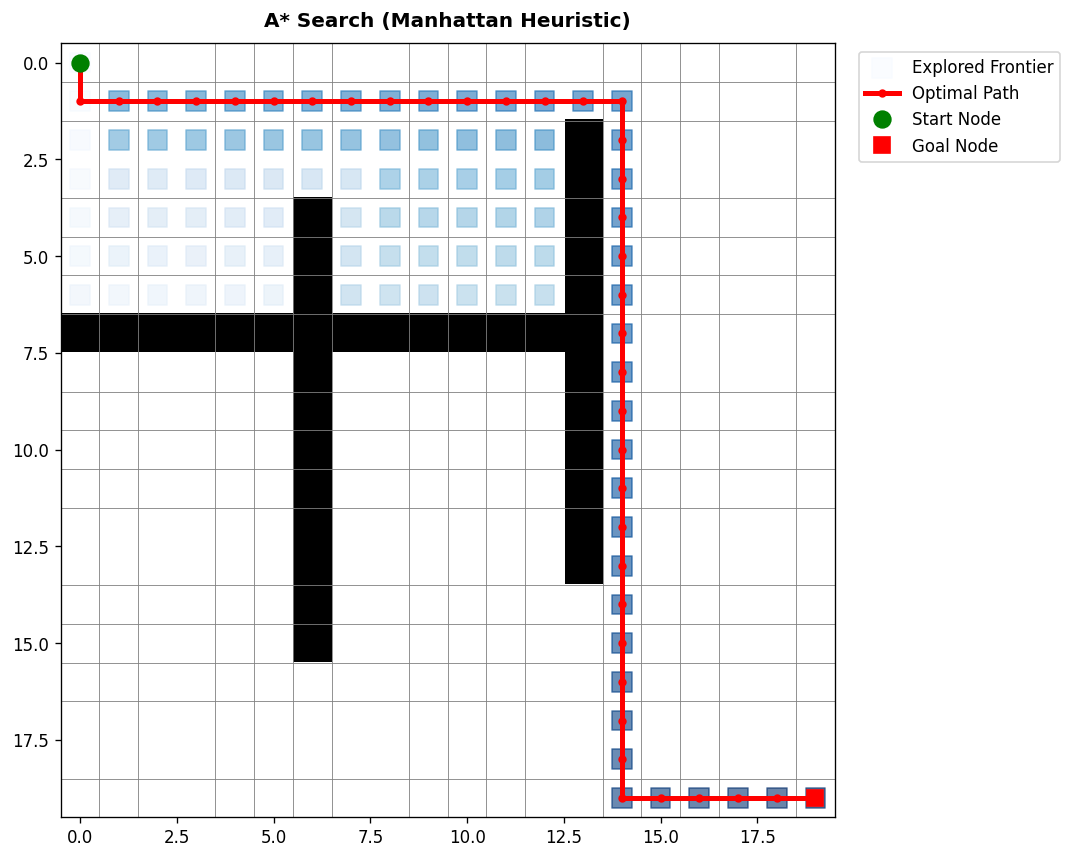

In [ ]:
def plot_search_grid(
    grid: np.ndarray,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    path: Optional[List[Tuple[int, int]]],
    explored: List[Tuple[int, int]],
    title: str = "A* Search Pathfinding Results"
):
    """
    Renders 2D graphical representation of grid pathfinding using Matplotlib.
    """
    fig, ax = plt.subplots(figsize=(9, 9))

    # Render base environment map
    ax.imshow(grid, cmap='binary', origin='upper')

    # Overlay explored nodes frontier colored by expansion chronology
    if explored:
        exp_rows, exp_cols = zip(*explored)
        color_gradient = np.linspace(0.3, 0.9, len(explored))
        ax.scatter(exp_cols, exp_rows, c=color_gradient, cmap='Blues', marker='s', s=140, alpha=0.6, label='Explored Frontier')

    # Overlay final reconstructed optimal path
    if path:
        path_rows, path_cols = zip(*path)
        ax.plot(path_cols, path_rows, color='red', linewidth=3, marker='o', markersize=4, label='Optimal Path')

    # Mark Start and Goal locations
    ax.plot(start[1], start[0], 'go', markersize=10, label='Start Node')
    ax.plot(goal[1], goal[0], 'rs', markersize=10, label='Goal Node')

    # Grid formatting parameters
    ax.set_xticks(np.arange(-.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', size=0)

    plt.title(title, fontsize=12, fontweight='bold', pad=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    plt.tight_layout()
    plt.show()

# Render visualization for loaded search data
plot_search_grid(sample_grid, start_coords, goal_coords, solution_path, expanded_nodes, "A* Search (Manhattan Heuristic)")

## Module 6: Comparative Algorithm Benchmarking

To understand the trade-offs between search strategies, students can compare three primary algorithm configurations on the loaded dataset:
1. **Uniform Cost Search (Dijkstra):** Set $h(n) = 0$. Guarantees path optimality but expands nodes isotropically in all directions.
2. **A* Search:** Combines $g(n)$ and $h(n)$. Balances targeted directionality with guaranteed path optimality.
3. **Greedy Best-First Search:** Set $g(n) = 0$, evaluating nodes strictly by $f(n) = h(n)$. Minimizes node expansions by driving directly toward the goal, but sacrifices path optimality.

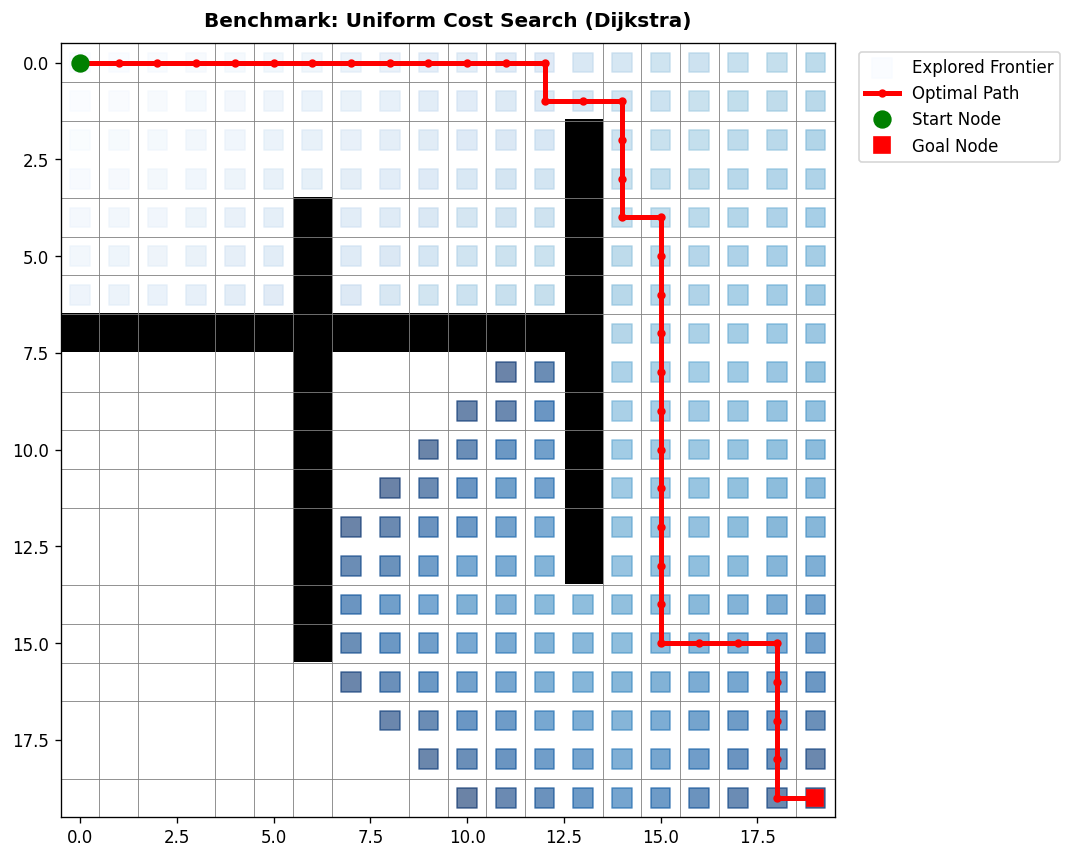

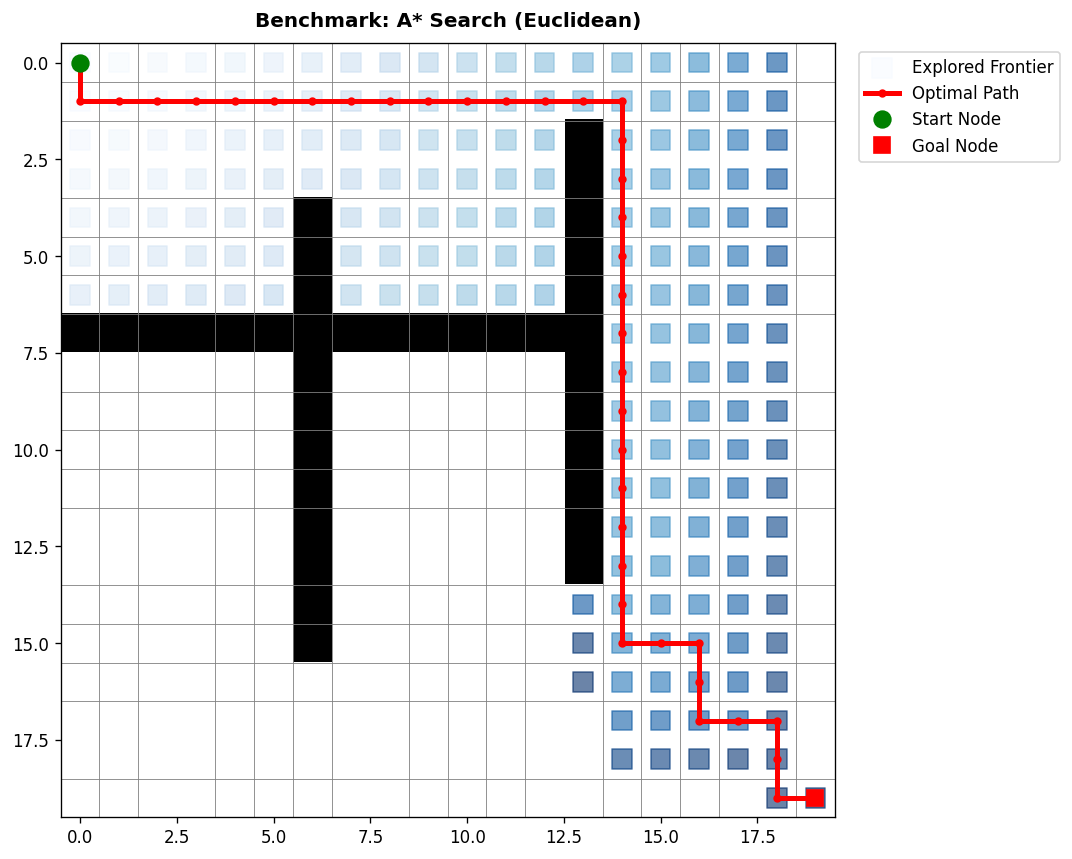

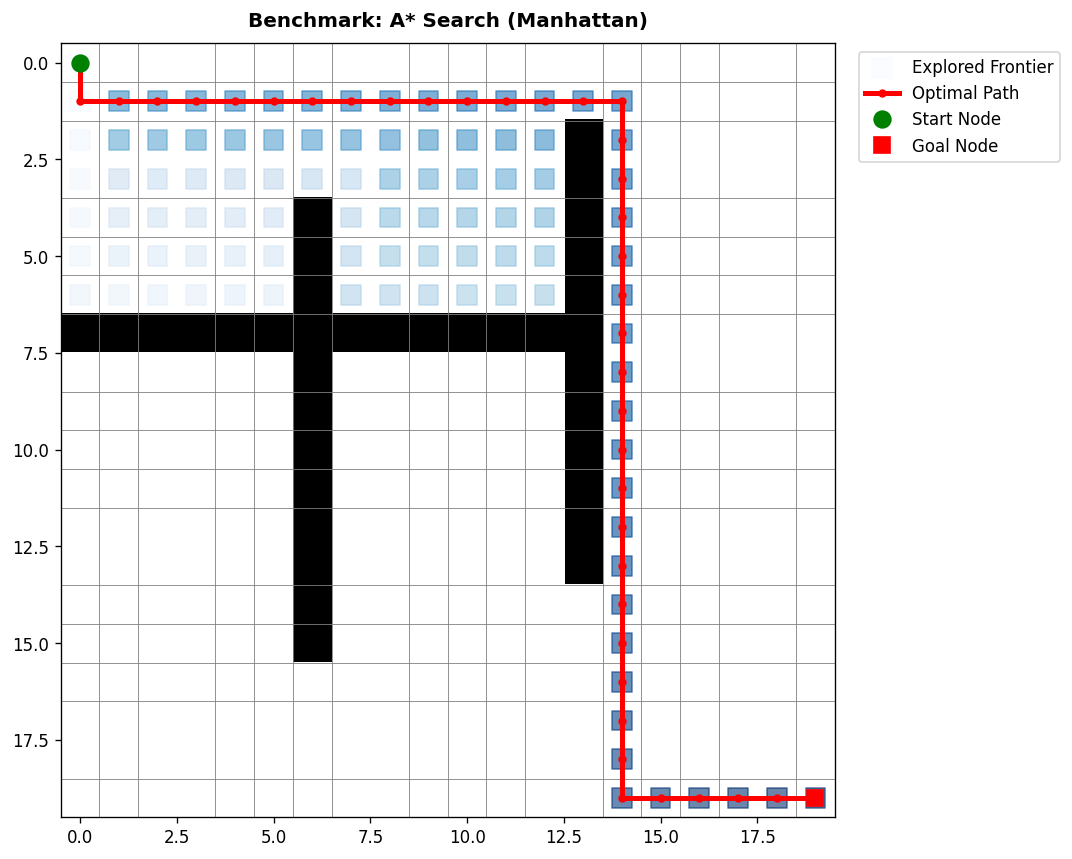

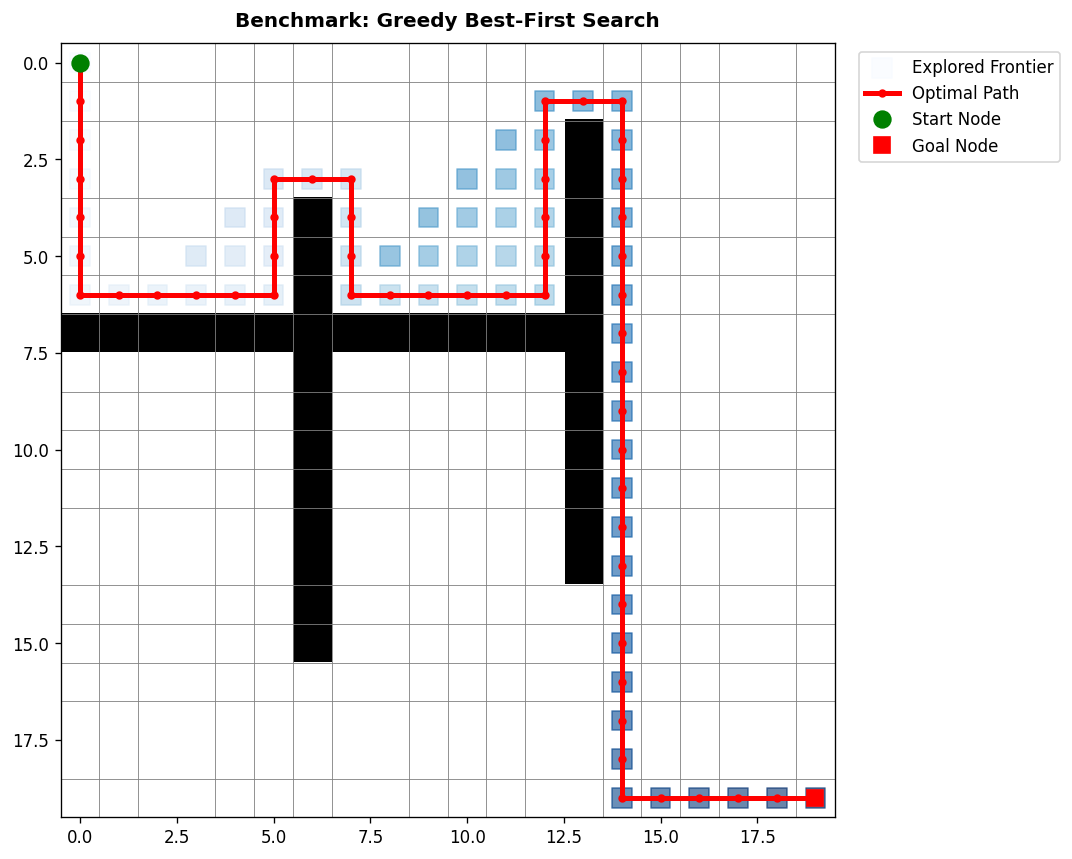

In [ ]:
def run_algorithm_benchmarks(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]):
    """
    Executes and compares Uniform Cost Search, A* Search, and Greedy Best-First Search.
    """
    # Define zero heuristic function for Uniform Cost Search
    zero_heuristic = lambda p1, p2: 0.0

    # Custom search routine for Greedy Best-First Search (evaluates f = h)
    def greedy_search(g_map, s, g, h_fn):
        rows, cols = g_map.shape
        start_node = Node(s, None, g=0.0, h=h_fn(s, g))
        open_heap = []
        heapq.heappush(open_heap, (start_node.h, start_node))
        closed = set()
        exp = []
        open_map = {s: start_node}

        while open_heap:
            _, curr = heapq.heappop(open_heap)
            if curr.position in closed:
                continue
            closed.add(curr.position)
            exp.append(curr.position)

            if curr.position == g:
                p = []
                c = curr
                while c:
                    p.append(c.position)
                    c = c.parent
                return p[::-1], exp, curr.g

            for dr, dc, cost_val in [(-1,0,1.0), (1,0,1.0), (0,-1,1.0), (0,1,1.0)]:
                n_pos = (curr.position[0]+dr, curr.position[1]+dc)
                if 0 <= n_pos[0] < rows and 0 <= n_pos[1] < cols:
                    if g_map[n_pos[0], n_pos[1]] == 0 and n_pos not in closed:
                        tent_g = curr.g + cost_val
                        n_node = Node(n_pos, curr, tent_g, h_fn(n_pos, g))
                        if n_pos not in open_map or tent_g < open_map[n_pos].g:
                            open_map[n_pos] = n_node
                            heapq.heappush(open_heap, (n_node.h, n_node))
        return None, exp, float('inf')

    benchmark_runs = [
        ("Uniform Cost Search (Dijkstra)", lambda: astar_search(grid, start, goal, zero_heuristic)),
        ("A* Search (Euclidean)", lambda: astar_search(grid, start, goal, euclidean_distance)),
        ("A* Search (Manhattan)", lambda: astar_search(grid, start, goal, manhattan_distance)),
        ("Greedy Best-First Search", lambda: greedy_search(grid, start, goal, manhattan_distance))
    ]

    results = []

    for name, run_fn in benchmark_runs:
        t0 = time.perf_counter()
        p, exp, c = run_fn()
        t1 = time.perf_counter()

        results.append({
            "Algorithm": name,
            "Path Length": len(p) if p else 0,
            "Total Cost": c,
            "Nodes Expanded": len(exp),
            "Execution Time (ms)": (t1 - t0) * 1000
        })

        plot_search_grid(grid, start, goal, p, exp, title=f"Benchmark: {name}")

    return results

# Run complete benchmark suite on data loaded from file
benchmark_results = run_algorithm_benchmarks(sample_grid, start_coords, goal_coords)